In [1]:
from rhopca.methods import kernelRhoPCA

import anndata as ad
import scanpy as sc

import spatialdata as sd
import spatialdata_plot
from spatialdata_io import visium_hd

import numpy as np

import os, time, session_info2

/home/kayla-jackson/opt/anaconda3/envs/rhopca/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/home/kayla-jackson/opt/anaconda3/envs/rhopca/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
/home/kayla-jackson/opt/anaconda3/envs/rhopca/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:533: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  inner = partial(_inner_join_spatialelement_t

## Load
Background data availabe from 10X Genomics [here](https://www.10xgenomics.com/datasets/320k_scFFPE_16-plex_GEM-X_FLEX)

In [3]:
visium_path = os.path.join("../data/Visium_V2_P2CRC")
alt_chrom_path = os.path.join("../data/scffpe_colorectal/")

In [4]:
adata_visium = sc.read_visium(
    visium_path,
    count_file = 'Visium_V2_Human_Colon_Cancer_P2_filtered_feature_bc_matrix.h5')

adata_visium.var_names_make_unique()

/tmp/ipykernel_2560012/3188647281.py:1: FutureWarning: Use `squidpy.read.visium` instead.
  adata_visium = sc.read_visium(
/home/kayla-jackson/opt/anaconda3/envs/rhopca/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [5]:
adata_chromium = sc.read_10x_h5(
    os.path.join(alt_chrom_path, "320k_scFFPE_16-plex_GEM-X_FLEX_Colorectal_BC3-4_count_sample_filtered_feature_bc_matrix.h5")
)

adata_chromium.var_names_make_unique()

## Basic processing

In [6]:
def process_adata(
    adata, 
    min_cells = 50, 
    max_mt_pct = 20, 
    min_counts = 50,
    max_counts = 250_000_000,
    min_genes = 10,
    hvg_flavor = 'seurat_v3',
    n_top_genes = 3_000,
    target_sum = 1e4,
    vishd=False,
):
    
    adata.var["mito"] = adata.var_names.str.startswith(("MT-", "mt-"))
    sc.pp.calculate_qc_metrics(adata, inplace=True, qc_vars=['mito'])
    print("Before filtering, there are {} obs and {} vars".format(*(adata.shape)))

    sc.pp.filter_genes(adata, min_cells=min_cells)
    print("After filtering vars, there are {} obs and {} vars".format(*(adata.shape)))

   
    mt_mask_cells = (adata.obs.pct_counts_mito <= max_mt_pct)
    adata = adata[mt_mask_cells].copy()

    print("After mt-filter, there are {} obs and {} vars".format(*(adata.shape)))
      
    sc.pp.filter_cells(adata, min_counts=min_counts)
    sc.pp.filter_cells(adata, max_counts=max_counts)
    sc.pp.filter_cells(adata, min_genes=min_genes)

    print("After filtering cells, there are {} obs and {} vars".format(*(adata.shape)))
    if not vishd: 
        sc.pp.highly_variable_genes(adata, flavor=hvg_flavor, n_top_genes=n_top_genes)

    sc.pp.normalize_total(adata, target_sum=target_sum)
    sc.pp.log1p(adata)
    sc.pp.pca(adata)

    return adata.copy()

In [7]:
adata_visium = process_adata(adata_visium)

Before filtering, there are 4269 obs and 18085 vars
After filtering vars, there are 4269 obs and 18035 vars
After mt-filter, there are 4269 obs and 18035 vars
After filtering cells, there are 4269 obs and 18035 vars


In [8]:
adata_chromium = process_adata(adata_chromium,max_mt_pct=10)

Before filtering, there are 52541 obs and 18129 vars
After filtering vars, there are 52541 obs and 14816 vars
After mt-filter, there are 52308 obs and 14816 vars
After filtering cells, there are 52308 obs and 14816 vars


In [9]:
genes_keep = adata_chromium[:,adata_chromium.var['highly_variable']].var_names.values

In [10]:
# adata_visium = adata_visium[:,genes_keep].copy()
adata_chromium = adata_chromium[:, genes_keep].copy() 

## Analysis with Visium V2

Plotting standard PCs

/tmp/ipykernel_2560012/3623755040.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_visium, color=['PC_1', 'PC_2', 'PC_3'], img_key=None,size=1.5)


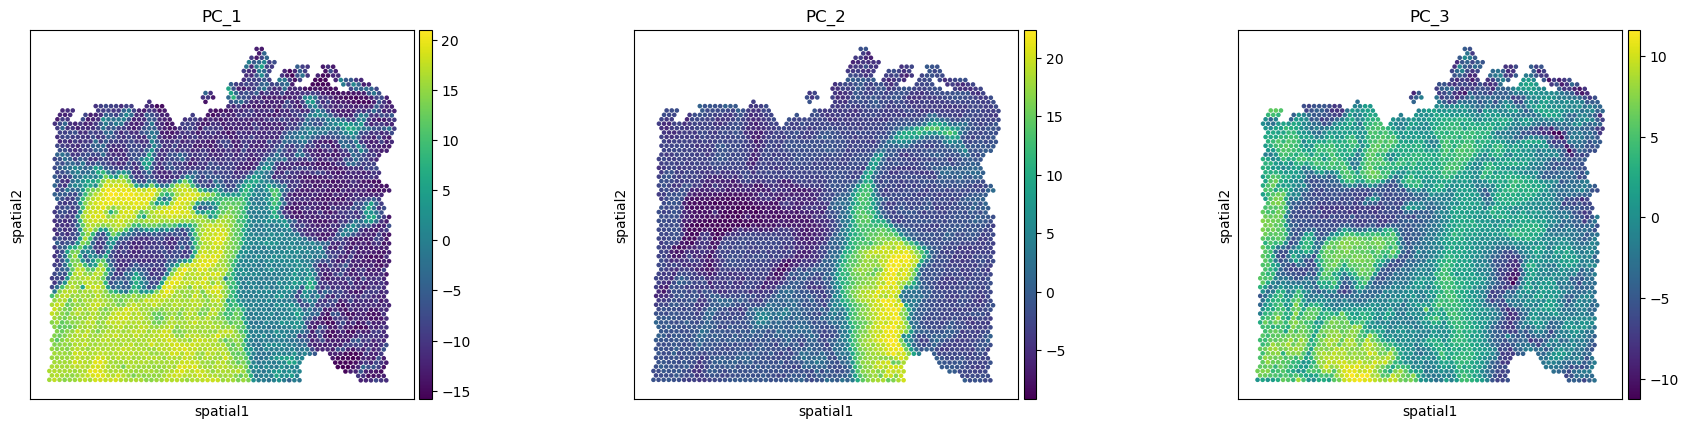

In [11]:
for i in range(3):
    adata_visium.obs[f'PC_{i+1}'] = adata_visium.obsm['X_pca'][:, i]

sc.pl.spatial(adata_visium, color=['PC_1', 'PC_2', 'PC_3'], img_key=None,size=1.5)

In [12]:
mdl = kernelRhoPCA(
    adata_visium, adata_chromium, 
    kernel = 'gaussian',
)

/home/kayla-jackson/projects/rhopca/src/rhopca/methods/kernel_rhopca.py:70: UserWarning: Gene sets do not match. Filtering to 2950 common genes (15085 dropped from target, 50 dropped from background). 
  warnings.warn(


In [13]:
st_fit = time.time() 
mdl.fit(verbose=True, method='tikhonov') 

print(f"krhoPCA Runtime: {(time.time() - st_fit)/60} minutes")

----------------------------------------
Covariance: Computing target covariance (kernel='gaussian')...
----------------------------------------
Covariance: Computing background covariance (no kernel)...
----------------------------------------
Covariance: Complete.
----------------------------------------
Eigendecomposition: Computing eigenvectors and eigenvalues...
----------------------------------------
Eigendecomposition: Complete.
----------------------------------------
Projecting: ...
----------------------------------------
: Finished computing projections.
krhoPCA Runtime: 1.423908293247223 minutes


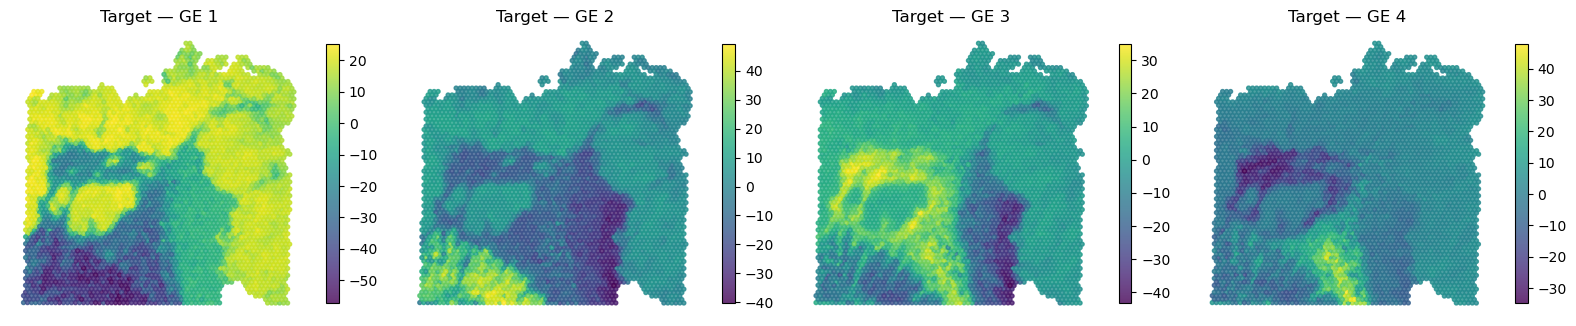

In [14]:
mdl.plot(components=(1,2,3,4), plot_type="spatial")

In [15]:
mdl.get_top_genes(component=1)

['SFRP2', 'NKX2-1', 'HAND2', 'THBS4', 'HOXD11']

In [16]:
mdl.get_top_genes(component=2)

['HAND2', 'THBS4', 'PYY', 'MS4A12', 'NKX2-1']

In [17]:
mdl.get_top_genes(component=3)

['SFRP2', 'MS4A12', 'PYY', 'ISM1', 'ADAMTS16']

## Computing environment

In [18]:
session_info2.session_info()

Package,Version
rhopca,1.0.0
anndata,0.12.10
scanpy,1.12
spatialdata,0.7.2
spatialdata-plot,0.3.2
spatialdata-io,0.6.0
numpy,2.4.3
Component,Info
Python,"3.13.12 | packaged by conda-forge | (main, Feb 5 2026, 05:53:46) [GCC 14.3.0]"
OS,Linux-4.18.0-338.el8.x86_64-x86_64-with-glibc2.28
